<a href="https://colab.research.google.com/github/devfullstackNeto/ia-ifmt-disciplinas/blob/main/estruturas-dados-algoritmos/aulas/Aula_31_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 – Introdução a Grafos em Python

Nesta aula vamos aprender:

- O que são grafos
- Como representá-los em Python
- Como percorrê-los
- Introdução à ideia de menor caminho
- Primeiros passos rumo ao algoritmo de Dijkstra


## O que é um Grafo?

Um grafo é composto por:

- Vértices (nós)
- Arestas (conexões entre nós)

Exemplo:

A --- B
|     |
C --- D

Aplicações:
- Redes sociais
- GPS
- Internet


In [1]:
print('Grafo: conjunto de nós conectados por arestas')

Grafo: conjunto de nós conectados por arestas


## Representando um grafo em Python

Usamos um dicionário:
- chave → nó
- valor → lista de vizinhos


In [2]:
# Grafo não ponderado
grafo = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A', 'D'],
    'D': ['B', 'C']
}

print(grafo)

{'A': ['B', 'C'], 'B': ['A', 'D'], 'C': ['A', 'D'], 'D': ['B', 'C']}


## Acessando vizinhos

Vamos ver os vizinhos do nó A

In [3]:
no = 'A'

print(f'Vizinhos de {no}:')
for vizinho in grafo[no]:
    print(vizinho)

Vizinhos de A:
B
C


In [4]:
for no in grafo:
  print(f'Vizinhos de {no}:',end=" ")
  for vizinho in grafo[no]:
    print(vizinho, end=" ")
  print()

Vizinhos de A: B C 
Vizinhos de B: A D 
Vizinhos de C: A D 
Vizinhos de D: B C 


## Percorrendo o grafo

Vamos visitar todos os nós a partir de um ponto inicial

In [5]:
def visitar(grafo, no, visitados):
    if no not in visitados:
        print(no)
        visitados.add(no)

        for vizinho in grafo[no]:
            visitar(grafo, vizinho, visitados)

visitados = set()
visitar(grafo, 'A', visitados)

A
B
D
C


In [6]:
!pip install networkx

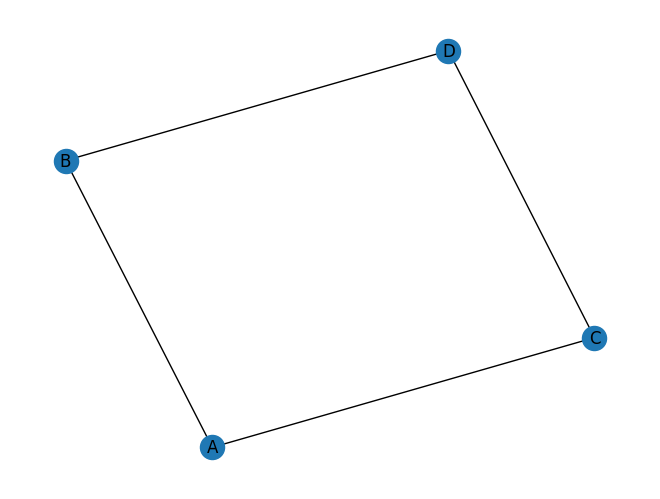

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for no in grafo:
    for vizinho in grafo[no]:
        G.add_edge(no, vizinho)

nx.draw(G, with_labels=True)

plt.show()

## Grafos com pesos

Agora cada aresta tem um custo associado

In [8]:
grafo_pesos = {
    'A': {'B': 2, 'C': 5},
    'B': {'A': 2, 'D': 1},
    'C': {'A': 5, 'D': 2},
    'D': {'B': 1, 'C': 2}
}

print(grafo_pesos)

{'A': {'B': 2, 'C': 5}, 'B': {'A': 2, 'D': 1}, 'C': {'A': 5, 'D': 2}, 'D': {'B': 1, 'C': 2}}


## Escolhendo o menor vizinho

Simulação de decisão local (não é Dijkstra completo)

In [9]:
def menor_vizinho(grafo, no):
    vizinhos = grafo[no]

    menor = None
    menor_custo = float('inf')

    for vizinho, custo in vizinhos.items():
        if custo < menor_custo:
            menor = vizinho
            menor_custo = custo

    return menor, menor_custo

no_atual = 'A'
proximo, custo = menor_vizinho(grafo_pesos, no_atual)

print(f'De {no_atual} vou para {proximo} com custo {custo}')

De A vou para B com custo 2


Nem sempre escolher o menor vizinho leva ao melhor caminho global.

É por isso que usamos o algoritmo de Dijkstra.

## Inicialização do algoritmo

- Nó inicial = 0
- Outros nós = infinito

In [10]:
distancias = {
    'A': 0,
    'B': float('inf'),
    'C': float('inf'),
    'D': float('inf')
}

visitados = set()

print('Distâncias iniciais:')
print(distancias)

Distâncias iniciais:
{'A': 0, 'B': inf, 'C': inf, 'D': inf}


## Atualizando distâncias

Ideia central do Dijkstra (relaxamento)

In [11]:
no_atual = 'A'

for vizinho, custo in grafo_pesos[no_atual].items():
    nova_distancia = distancias[no_atual] + custo

    if nova_distancia < distancias[vizinho]:
        distancias[vizinho] = nova_distancia

print('Após atualização:')
print(distancias)

Após atualização:
{'A': 0, 'B': 2, 'C': 5, 'D': inf}


## Escolhendo próximo nó

Selecionamos o nó não visitado com menor distância

In [12]:
def escolher_proximo(distancias, visitados):
    menor = None
    menor_dist = float('inf')

    for no in distancias:
        if no not in visitados and distancias[no] < menor_dist:
            menor = no
            menor_dist = distancias[no]

    return menor

proximo = escolher_proximo(distancias, visitados)
print('Próximo nó:', proximo)

Próximo nó: A


# Conclusão

Você deu o primeiro passo em um dos algoritmos mais importantes da computação.

Na próxima aula vamos montar o Dijkstra completo.